In [1]:
import numpy as np
import pandas as pd 
import os
import spacy
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mdtalhask/ai-powered-resume-screening-dataset-2025/AI_Resume_Screening.csv
/kaggle/input/datasets/kawsertalukder/resume-screening-dataset4500/ml_resume_dataset_4500.csv
/kaggle/input/datasets/ramzybakir/ai-generated-resume-dataset/SYRA_Generated_Resumes_dataset.csv
/kaggle/input/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.json
/kaggle/input/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.csv


In [2]:
resume = pd.read_csv('../input/datasets/ramzybakir/ai-generated-resume-dataset/SYRA_Generated_Resumes_dataset.csv')
resume.head()
resume.columns
# resume.shape
# resume['str_resume'][0]

Index(['application_name', 'str_resume'], dtype='object')

In [3]:
'''
FEATURE EXTRACTION
'''
import re

def extract_name(text):
    first_line = text.strip().split("\n")[0]
    return first_line.strip()

def extract_job_title(text):
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    if len(lines) > 1:
        title_line = lines[1]
         # Split at | and keep first part
        title = title_line.split("|")[0].strip()
        return title
    return None
    
def extract_section(text, section_name):
    pattern = rf"{section_name}\s*(.*?)\s*(?=\n[A-Z][A-Za-z ]+\n|$)"
    match = re.search(pattern, text, re.S | re.I)
    return match.group(1).strip() if match else None

def extract_skills(text):
    skills_text = extract_section(text, "Skills")
    if skills_text:
        skills = re.findall(r"•\s*(.*)", skills_text)
        return ", ".join(skills)
    return None

def extract_education(text):
    edu_text = extract_section(text, "Education")
    if edu_text:
        edu = re.findall(r"•\s*(.*)", edu_text)
        return " | ".join(edu)
    return None
    
def extract_certifications(text):
    cert_text = extract_section(text, "Certifications")
    if cert_text:
        certs = re.findall(r"•\s*(.*)", cert_text)
        return " | ".join(certs)
    return None

def extract_experience_years(text):
    match = re.search(r'(\d+)\+?\s+years? of experience', text, re.I)
    if match:
        return int(match.group(1))
    return None



In [4]:
resume['name'] = resume['str_resume'].apply(extract_name)
resume['job_role'] = resume['str_resume'].apply(extract_job_title)
resume['skills'] = resume['str_resume'].apply(extract_skills)
resume['education'] = resume['str_resume'].apply(extract_education)
resume['certifications'] = resume['str_resume'].apply(extract_certifications)
resume['experience_years'] = resume['str_resume'].apply(extract_experience_years)
# resume[['name','job_role','skills','education','certifications','experience_years']].head()
# resume['certifications'][0]
# resume.shape # 721
resume.columns


Index(['application_name', 'str_resume', 'name', 'job_role', 'skills',
       'education', 'certifications', 'experience_years'],
      dtype='object')

In [5]:
resume_4500 = pd.read_csv('../input/datasets/kawsertalukder/resume-screening-dataset4500/ml_resume_dataset_4500.csv')
# resume_4500 = resume_4500.drop(columns=['has_portfolio','raw_text','label','id'])
resume_4500 = resume_4500.drop(columns=['has_portfolio','id','raw_text'])
# resume_4500.head(1) 
# resume_4500['raw_text'][0]
resume_4500.columns
# resume_4500.shape # 4500

Index(['name', 'years_experience', 'highest_degree', 'skills', 'current_title',
       'label'],
      dtype='object')

In [6]:
resume_df = pd.read_csv('../input/datasets/mdtalhask/ai-powered-resume-screening-dataset-2025/AI_Resume_Screening.csv')
resume_df = resume_df.drop(columns=['Salary Expectation ($)','Projects Count','AI Score (0-100)','Resume_ID'])
# resume_df.head()
resume_df.columns
# resume_df.shape # 1000


Index(['Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications',
       'Job Role', 'Recruiter Decision'],
      dtype='object')

In [7]:
job_descriptions_df = pd.read_csv('../input/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.csv')
job_descriptions_df = job_descriptions_df.drop(columns=['ExperienceLevel','JobID'])
# job_descriptions_df.head()
job_descriptions_df.columns
# job_descriptions_df.shape # 1068

Index(['Title', 'YearsOfExperience', 'Skills', 'Responsibilities', 'Keywords'], dtype='object')

In [8]:
'''
RENAMING COLUMNS
'''
import re

resume = resume.rename(columns={
    'skills': 'resume_skills',
    'experience_years': 'resume_experience_years',
}).copy()


resume_df = resume_df.rename(columns={
    'Name':'name',
    'Skills': 'resume_skills',
    'Experience (Years)': 'resume_experience_years',
    'Education': 'education',
    'Certifications': 'certifications',
    'Job Role': 'job_role',
    'AI Score (0-100)': 'Match Score',
}).copy()

resume_4500['certifications'] = np.nan
resume_4500 = resume_4500.rename(columns={
    'skills': 'resume_skills',
    'years_experience': 'resume_experience_years',
    'highest_degree':'education',
    'current_title':'job_role'
}).copy()

job_df = job_descriptions_df.rename(columns={
    'Skills': 'required_skills',
    'YearsOfExperience': 'required_experience_years',
    'Title': 'job_role',
    'Keywords': 'keywords'
}).copy()


In [9]:
# target harmonization
def assign_unified_truth(row):
    # 1. If it came from the 'Recruiter Decision' dataset
    if 'Recruiter Decision' in row and pd.notna(row['Recruiter Decision']):
        return 1 if str(row['Recruiter Decision']).lower() == 'hire' else 0
    
    # 2. If it came from the 'label' dataset
    if 'label' in row and pd.notna(row['label']):
        return int(row['label'])
    
    # 3. For the dataset with NO labels (The Heuristic Approach)
    # We define "Truth" as someone who has the right Title AND at least 80% of the Exp
    if row['resume_experience_years'] >= (row['required_experience_years_num'] * 0.8):
        # Optional: Add a check for at least 1 hard-skill match
        if row['skill_match_count'] > 0:
            return 1
            
    return 0


In [10]:
'''
MERGE RESUME
'''
def clean_role(x):
    if pd.isna(x):
        return ""
    return str(x).lower().strip()

# Clean job_role text
def clean_role(x):
    if pd.isna(x):
        return ""
    return str(x).lower().strip()

def clean_name(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip() 
    x = re.sub(r'\s+', ' ', x)  # replace multiple spaces with single
    return x

resume_df['name'] = resume_df['name'].apply(clean_name)
resume['name'] = resume['name'].apply(clean_name)
resume_4500['name'] = resume_4500['name'].apply(clean_name)


resume_df['job_role'] = resume_df['job_role'].apply(clean_role)
resume['job_role'] = resume['job_role'].apply(clean_role)
resume_4500['job_role'] = resume_4500['job_role'].apply(clean_role)

merged_resume = pd.concat(
    [resume, resume_df, resume_4500],
    axis=0,
    ignore_index=True
)
# merged_resume.columns
# merged_resume['resume_experience_years'].value_counts()
# merged_resume['resume_experience_years'].nunique()
# len(merged_resume)
# merged_resume.head()
# merged_resume.shape # 6221
merged_resume.columns

Index(['application_name', 'str_resume', 'name', 'job_role', 'resume_skills',
       'education', 'certifications', 'resume_experience_years',
       'Recruiter Decision', 'label'],
      dtype='object')

In [11]:
'''
Data Preprocessing

Standardize(dtypes)
    -The years of experience dtypes differing : resume(int64) and job_descriptions(object)
    -Need them as int64 for both dataframes

Nomarlize text (skills,keywords,title/job role) : lowercase everything,handle delimiters and strip whitespace
'''
import re
# Standardize dtypes
def parse_experience(x):
    if pd.isna(x):
        return None

    # extract all numbers in string
    nums = re.findall(r'\d+', x)
    # take minimum value (first number)
    # return int(nums[1])
    # take maximum value (second number)
    return int(nums[-1])



job_df['required_experience_years_num'] = (
    job_df['required_experience_years']
    .apply(parse_experience)
    # .astype('Int64')
)

# Normalize text
def clean_text(text):
    if pd.isna(text):
        return [] 
    
    text = text.lower().strip()
    # Split on comma, semicolon, or pipe
    items = re.split(r'[,;|]', text) 
    
    # Clean each item: remove special chars but keep +, ., and -
    cleaned_items = []
    for t in items:
        t = t.strip()
        if t:
            # Preserve 'c++', '.net', 'react-native'
            t = re.sub(r'[^\w\+\.\- ]', '', t)
            cleaned_items.append(t)
            
    return list(set(cleaned_items)) # set() removes accidental duplicates in the same row

job_df['job_role'] = job_df['job_role'].apply(clean_role)
job_df.head()



,job_role,required_experience_years,required_skills,Responsibilities,keywords,required_experience_years_num
0,.net developer,0-1,C#; VB.NET basics; .NET Framework; .NET Core f...,Assist in coding and debugging applications; L...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...,1
1,.net developer,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Write simple C# programs under guidance; Suppo...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...,1
2,.net developer,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Contribute to development of small modules; As...,.NET; C#; ASP.NET MVC; SQL Server; Entity Fram...,1
3,.net developer,0-1,C#; .NET Framework; ASP.NET basics; SQL Server...,Support in software design documentation; Assi...,.NET; C#; SQL Server; Entity Framework; ASP.NET,1
4,.net developer,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Learn to design and build ASP.NET applications...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...,1


In [13]:
merged_resume['resume_skills_list'] = merged_resume['resume_skills'].map(clean_text)
job_df['keywords_list'] = job_df['keywords'].map(clean_text)
job_df['required_skills_list'] = job_df['required_skills'].map(clean_text)
# screening_df.head()
# merged_resume.columns
# job_df.head()
job_df.columns

Index(['job_role', 'required_experience_years', 'required_skills',
       'Responsibilities', 'keywords', 'required_experience_years_num',
       'keywords_list', 'required_skills_list'],
      dtype='object')

In [14]:
'''
MERGE Dataframes
'''
job_cols = [
    'job_role',
    'required_experience_years_num',
    'required_skills',
    'keywords',
    'required_skills_list',
    'keywords_list',
]

merged_df = merged_resume.merge(
    job_df[job_cols],
    on='job_role',
    # how='left'
    how='inner'
)

#IMPUTATION : EXPERIENCE YEARS ; impute by job role's median
role_median_exp = merged_df.groupby('job_role')['resume_experience_years'].median()
merged_df['resume_experience_years'] = merged_df.apply(
    lambda row: role_median_exp[row['job_role']]
    if pd.isna(row['resume_experience_years'])
    else row['resume_experience_years'],
    axis=1
)

#  impute by job role's median
role_median_exp = merged_df.groupby('job_role')['required_experience_years_num'].median()
merged_df['required_experience_years_num'] = merged_df.apply(
    lambda row: role_median_exp[row['job_role']]
    if pd.isna(row['required_experience_years_num'])
    else row['required_experience_years_num'],
    axis=1
)

# merged_df['required_experience_years_num'].isna().sum().sum()
# merged_df['resume_experience_years'].isna().sum().sum() 
# merged_df['required_skills'].isna().sum().sum() 
# merged_df['keywords'].isna().sum().sum() 
# merged_df['required_skills_list'].isna().sum().sum() 
merged_df['keywords_list'].isna().sum().sum() 


critical_job_fields = ['required_skills','required_skills_list', 'keywords','keywords_list']
merged_df = merged_df.drop(columns=['str_resume','application_name'])
merged_df = merged_df.dropna(subset=critical_job_fields)

# 4. Check the ROW count
# print(f"Rows left: {len(merged_df)}")  # 14481
# merged_df.shape #14481

# merged_df.head()
merged_df.columns

Index(['name', 'job_role', 'resume_skills', 'education', 'certifications',
       'resume_experience_years', 'Recruiter Decision', 'label',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list'],
      dtype='object')

In [15]:
'''
CONTEXT STRINGS
'''

def create_resume_context(row):
    skills = " ".join(row['resume_skills_list'])
    return f"Candidate with {row['resume_experience_years']} years of experience. Skills: {skills}. Education: {row['education']}. Certifications: {row['certifications']}."

def create_job_context(row):
    # Ensure we handle NaN or empty lists
    req_skills = " ".join(row['required_skills_list']) if isinstance(row['required_skills_list'], list) else ""
    keywords = " ".join(row['keywords_list']) if isinstance(row['keywords_list'], list) else ""
    return f"Job requires {row['required_experience_years_num']} years of experience. Required skills: {req_skills}. Keywords: {keywords}."

merged_df['resume_text_for_bert'] = merged_df.apply(create_resume_context, axis=1)
merged_df['job_text_for_bert'] = merged_df.apply(create_job_context, axis=1)
merged_df.columns
# merged_df.head()
# print(f'Rows left',len(merged_df))

Index(['name', 'job_role', 'resume_skills', 'education', 'certifications',
       'resume_experience_years', 'Recruiter Decision', 'label',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list',
       'resume_text_for_bert', 'job_text_for_bert'],
      dtype='object')

In [17]:
'''
EXPERIENCE GAP : What job wants vs candidate has
Positive number = candidate exceeds requirements
Negative number = candidate lacks years of experience
'''
# merged_df['experience_gap'] = merged_df['required_experience_years_num'] - merged_df['resume_experience_years']
merged_df['experience_gap'] = merged_df['resume_experience_years'] - merged_df['required_experience_years_num']- merged_df['resume_experience_years'] 
merged_df.columns

Index(['name', 'job_role', 'resume_skills', 'education', 'certifications',
       'resume_experience_years', 'Recruiter Decision', 'label',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list',
       'resume_text_for_bert', 'job_text_for_bert', 'experience_gap'],
      dtype='object')

In [18]:
'''
SKILLS OVERLAP
Use spaCy for semantic entity matching
'''
! python -m spacy download en_core_web_lg
nlp = spacy.load("en_core_web_lg")

def calculate_spacy_match(row):
    res_skills = row['resume_skills_list']
    job_skills = row['required_skills_list']
    
    if not isinstance(res_skills, list) or not isinstance(job_skills, list):
        return []

    matched = []
    # Create docs for job skills once to save time
    job_docs = [nlp(skill.lower()) for skill in job_skills]
    res_docs = [nlp(skill.lower()) for skill in res_skills]

    for j_doc in job_docs:
        for r_doc in res_docs:
            # Check if either one is a substring OR if they are semantically similar
            # 0.8 is a high threshold for "conceptually identical"
            if j_doc.text in r_doc.text or r_doc.text in j_doc.text or j_doc.similarity(r_doc) > 0.82:
                matched.append(j_doc.text)
                break # Move to the next job skill
                
    return list(set(matched))

# Apply the new logic
merged_df['matched_skills_list'] = merged_df.apply(calculate_spacy_match, axis=1)
merged_df['skill_match_count'] = merged_df['matched_skills_list'].apply(len)
# merged_df[['expanded_resume_skills', 'required_skills_list']].iloc[0].values
merged_df[['resume_skills_list', 'required_skills_list']].iloc[0].values

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/tmp/ipykernel_55/3202258851.py:24: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  if j_doc.text in r_doc.text or r_doc.text in j_doc.text or j_doc.similarity(r_doc) > 0.82:


array([list(['cloud platforms  aws', 'google cloud', 'deep learning  cnns', 'plotly', 'spacy', 'r', 'pytorch', 'nlp nltk', 'c++', 'yolo', 'dash', 'bert', 'flink', 'hadoop', 'ml frameworks  tensorflow', 'big data apache spark', 'azure', 'version control  git', 'rnns', 'data visualization  seaborn', 'programming languages  python', 'keras', 'fastai', 'gans', 'computer vision  opencv', 'gitlab']),
       list(['classification', 'sql', 'tableau', 'javascala', 'hadoop', 'spark', 'powerbi', 'azure', 'reinforcement learning', 'aws', 'python', 'etl pipelines', 'nlp', 'feature engineering', 'regression', 'r'])],
      dtype=object)

In [19]:
# target harmonization
merged_df['y_true'] = merged_df.apply(assign_unified_truth, axis=1)
merged_df.columns

Index(['name', 'job_role', 'resume_skills', 'education', 'certifications',
       'resume_experience_years', 'Recruiter Decision', 'label',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list',
       'resume_text_for_bert', 'job_text_for_bert', 'experience_gap',
       'matched_skills_list', 'skill_match_count', 'y_true'],
      dtype='object')

In [20]:
'''
TRANSFORMER EMBEDDINGS 
SBERT which uses the Siamese Network Architecture
Allows creation of a fixed-size vector (embedding) for the Resume and the Job Description separately, 
then calculates the distance between them
'''
from sentence_transformers import SentenceTransformer, util
import torch

# Load large model
model = SentenceTransformer('all-mpnet-base-v2')

'''
2. Prepare the text for BERT 
Join list (skills) into a single string(s) for the model to read
'''
def safe_join(x):
    return " ".join(x) if isinstance(x, list) else ""

merged_df['resume_text'] = merged_df['resume_skills_list'].apply(safe_join)
merged_df['job_text'] = merged_df['required_skills_list'].apply(safe_join)

'''
3. Generate Embeddings
'''
resume_embeddings = model.encode(merged_df['resume_text'].tolist(), convert_to_tensor=True)
job_embeddings = model.encode(merged_df['job_text'].tolist(), convert_to_tensor=True)


'''
4. Calculate Cosine Similarity
util.cos_sim returns a matrix; we take the diagonal since we matched them in the merge
'''
cosine_scores = util.cos_sim(resume_embeddings, job_embeddings)
merged_df['semantic_similarity_score'] = torch.diag(cosine_scores).tolist()

# 5. Normalize to 0-100 for the UI
merged_df['semantic_similarity_score'] = (merged_df['semantic_similarity_score'] * 100).round(2)
# merged_df.columns
# merged_df['semantic_similarity_score'] # 510 rows
# merged_df['semantic_similarity_score'].head(10)
# merged_df.loc[merged_df['semantic_similarity_score'] == 0 ] # 0
# merged_df.loc[merged_df['semantic_similarity_score'] > 0] # 500 rows
# missing_semantic = merged_df['semantic_similarity_score'].isna()
# missing_semantic.sum() # 0
max(merged_df['semantic_similarity_score'])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

89.7

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))

# 2. Reshape and Fit-Transform
# MinMaxScaler expects a 2D array, so we use .values.reshape(-1, 1)
scores_2d = merged_df['semantic_similarity_score'].values.reshape(-1, 1)
merged_df['boosted_semantic_score'] = scaler.fit_transform(scores_2d)

# 3. Round for the UI
merged_df['boosted_semantic_score'] = merged_df['boosted_semantic_score'].round(2)
# Fill NaN values to prevent the calculation from breaking or returning NaN
merged_df['boosted_semantic_score'] = merged_df['boosted_semantic_score'].fillna(0)
merged_df['skill_match_count'] = merged_df['skill_match_count'].fillna(0)
merged_df['resume_experience_years'] = merged_df['resume_experience_years'].fillna(0)
merged_df['required_experience_years_num'] = merged_df['required_experience_years_num'].fillna(0)
# max(merged_df['boosted_semantic_score']) # 100
merged_df.shape # 14481

(14481, 24)

In [22]:
'''
RANKING
'''
def calculate_final_score_v5(row):
    semantic_weight = 0.5
    skill_overlap_weight = 0.3
    exp_weight = 0.2
    
    # 1. Use the boosted score (Now scales up to 100)
    s_score = row.get('boosted_semantic_score', 0)
    
    # 2. Skill Overlap 
    req_list = row.get('required_skills_list', [])
    req_count = len(req_list) if isinstance(req_list, list) else 0
    match_count = row.get('skill_match_count', 0)
    
    if req_count > 0:
        # We use a 'Soft Floor'—if they match at least one skill and AI likes them, 
        # don't let the overlap score be 0.
        raw_overlap = (match_count / req_count) * 100
        overlap_score = max(raw_overlap, 40) if (match_count > 0 and s_score > 60) else raw_overlap
    else:
        overlap_score = 100
    
    # 3. Experience Score (Capped at 100)
    res_exp = row.get('resume_experience_years', 0)
    req_exp = row.get('required_experience_years_num', 0)
    if req_exp <= 0:
        exp_score = 100
    elif res_exp >= req_exp:
        exp_score = 100
    else:
        exp_score = (res_exp / req_exp) * 100
        
    final = (s_score * semantic_weight) + (overlap_score * skill_overlap_weight) + (exp_score * exp_weight)
    return round(float(final), 2)

# Apply the final version
merged_df['Final_Match_Score'] = merged_df.apply(calculate_final_score_v5, axis=1)
max(merged_df['Final_Match_Score'])
# merged_df.columns
# merged_df['Final_Match_Score'] # 510 rows
# merged_df.loc[merged_df['Final_Match_Score'] == 0 ] # 0
# merged_df.loc[merged_df['Final_Match_Score'] > 0] # 509 rows
# missing_scores = merged_df['Final_Match_Score'].isna()
# missing_scores.sum() # 0

92.27

In [23]:
'''
TF-IDF : KEYWORD-BASED
TF-IDF likely ranked a candidate at the top who simply "spammed" the word "Cybersecurity" 50 times, even if they had no experience. 
'''
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch

# initialize vectorizer
tfidf_vec = TfidfVectorizer()

# FIT & TRANSFORM vocabulary
all_text = merged_df['resume_text'].tolist() + merged_df['job_text'].tolist()
tfidf_matrix = tfidf_vec.fit_transform(all_text)

# split back to resume and jobs
res_tfidf = tfidf_matrix[:len(merged_df)]
job_tfidf = tfidf_matrix[len(merged_df):]

# Calculate Similarity (row by row)
tfidf_scores = []
for i in range(len(merged_df)):
    score = cosine_similarity(res_tfidf[i], job_tfidf[i])[0][0]
    tfidf_scores.append(round(score * 100, 2))

merged_df['tfidf_similarity'] = tfidf_scores
merged_df['tfidf_similarity'].head()
max(merged_df['tfidf_similarity'])
# merged_df.columns


61.84

In [24]:
'''
WORD2VEC : SEMANTIC SIMILARITY
Word2Vec creates vectors where words used in similar contexts are close together. 
Since you are using spaCy's en_core_web_md, 
you are actually already using GloVe (similar to Word2Vec).

Strength: Understands that "Linux" and "Ubuntu" are related.
Weakness: It averages all words in a document, 
which can "blur" the meaning if the resume is too long.

Word2Vec gives high scores (70%+) to almost everyone. 
This creates a "crowded" top of the list where the truly good candidates get buried under "average" candidates who just
happen to use similar technology words. 
It lacks the precision to push the best to the very top
'''
# Since we have spaCy docs, we can extract the average vector for each text
merged_df['w2v_similarity'] = merged_df.apply(
    lambda row: nlp(row['resume_text']).similarity(nlp(row['job_text'])) * 100, 
    axis=1
).round(2)
# merged_df['w2v_similarity'].head()
# merged_df.columns
max(merged_df['w2v_similarity'])

/tmp/ipykernel_55/2340563768.py:18: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  lambda row: nlp(row['resume_text']).similarity(nlp(row['job_text'])) * 100,


96.45

In [27]:
'''
MODELS COMPARISON
'''
# Compare the top candidate across all three models
comparison_df = merged_df[['Final_Match_Score', 'tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score','name']].head()
# comparison_df = merged_df[['Final_Match_Score', 'tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score']].head()
print("Comparison of Matching Engines:")
display(comparison_df)


Comparison of Matching Engines:


,Final_Match_Score,tfidf_similarity,w2v_similarity,semantic_similarity_score,boosted_semantic_score,name
0,77.23,12.60,83.79,63.19,73.22,ahmed mansour
1,72.05,11.52,76.01,68.27,78.35,aidan murphy
2,30.46,0.00,0.00,11.42,20.93,# aisha patel
3,77.89,29.50,81.99,63.74,73.78,alejandro gómez
4,71.19,31.29,83.51,62.36,72.38,alejandro gómez


In [28]:
#  model comparison based on certain criteria
merged_df['is_objectively_good'] = (
    (merged_df['resume_experience_years'] >= merged_df['required_experience_years_num']) & 
    (merged_df['skill_match_count'] >= 3)
).astype(int)

comparison_df = merged_df[['is_objectively_good', 'tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score','name']].head()

print("Comparison of Matching Engines:")
display(comparison_df)

Comparison of Matching Engines:


,is_objectively_good,tfidf_similarity,w2v_similarity,semantic_similarity_score,boosted_semantic_score,name
0,1,12.60,83.79,63.19,73.22,ahmed mansour
1,0,11.52,76.01,68.27,78.35,aidan murphy
2,0,0.00,0.00,11.42,20.93,# aisha patel
3,1,29.50,81.99,63.74,73.78,alejandro gómez
4,1,31.29,83.51,62.36,72.38,alejandro gómez


In [29]:
# co-relation of 3 models
merged_df['is_objectively_good'] = (
    (merged_df['resume_experience_years'] >= merged_df['required_experience_years_num']) & 
    (merged_df['skill_match_count'] >= 3)
).astype(int)

correlations = merged_df[['is_objectively_good', 'tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score', 'boosted_semantic_score']].corr()
print(correlations['is_objectively_good'])

is_objectively_good          1.000000
tfidf_similarity             0.651698
w2v_similarity               0.320918
semantic_similarity_score    0.595439
boosted_semantic_score       0.595441
Name: is_objectively_good, dtype: float64


In [31]:
'''
To prove which model is actually "smarter," we use Precision @ K

Word2Vec lacks context, it often finds a broad, "mushy" similarity between documents. 
It sees "Computer," "Python," and "Linux" and says, "Yep, these are all technology words," giving a high baseline score.

SBERT's "Strictness" looks at the entire structure and intent of the sentence. 
It is much more "cynical." It doesn't just see the word "Python"; it looks at how it's used.
If the job asks for "Python for API development" and the resume says "Learned Python in college," 
SBERT recognizes the gap in expertise level, leading to a lower, more realistic similarity score.
'''
def calculate_precision_at_k(recommended_list, ground_truth_list, k):
    top_k = recommended_list[:k]
    relevant_count = len(set(top_k) & set(ground_truth_list))
    return relevant_count / k

'''
GROUND TRUTH ON RELEVANT CANDIDATE
Has the exact Job Title (String match).
Has >= required experience years.
Has at least 3 exact keyword matches in their skills list.
'''
# true_relevance_criteria = (
#     (merged_df['resume_experience_years'] >= merged_df['required_experience_years_num']) &
#     (merged_df['skill_match_count'] >= 3)
# )

true_relevance_criteria = (
    (merged_df['resume_experience_years'] >= merged_df['required_experience_years_num']) &
    (merged_df['skill_match_count'] >= 1)
)

actual_top_candidates = merged_df[true_relevance_criteria]['name'].tolist()

# 1. Get Ranking for models
sbert_rank = merged_df.sort_values('semantic_similarity_score', ascending=False)['name']
w2v_rank = merged_df.sort_values('w2v_similarity', ascending=False)['name']
tfidf_rank = merged_df.sort_values('tfidf_similarity', ascending=False)['name']
boosted_semantic_rank = merged_df.sort_values('boosted_semantic_score', ascending=False)['name']


# Calculate P@3 (Precision at 3)
p3_sbert = calculate_precision_at_k(sbert_rank,actual_top_candidates, 5)
p3_w2v = calculate_precision_at_k(w2v_rank,actual_top_candidates, 5)
p3_tfidf = calculate_precision_at_k(tfidf_rank,actual_top_candidates, 5)
p3_bss = calculate_precision_at_k(boosted_semantic_rank, actual_top_candidates, 5)

print(f"Precision @ 3 (SBERT): {p3_sbert:.2f}")
print(f"Precision @ 3 (Word2Vec): {p3_w2v:.2f}")
print(f"Precision @ 3 (TF-IDF): {p3_tfidf:.2f}")
print(f"Precision @ 3 (Boosted Semantic): {p3_bss:.2f}")

Precision @ 3 (SBERT): 0.60
Precision @ 3 (Word2Vec): 0.40
Precision @ 3 (TF-IDF): 0.20
Precision @ 3 (Boosted Semantic): 0.60


/tmp/ipykernel_55/3755719666.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=precision_values, palette='magma')


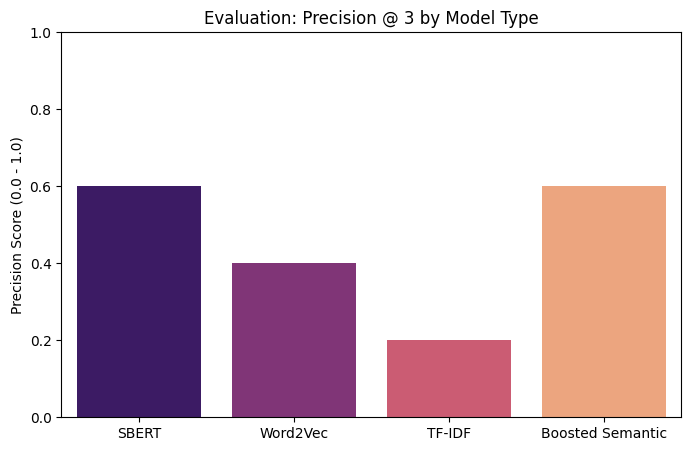

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
models = ['SBERT', 'Word2Vec', 'TF-IDF','Boosted Semantic']
precision_values = [p3_sbert, p3_w2v,p3_tfidf,p3_bss]

sns.barplot(x=models, y=precision_values, palette='magma')
plt.title('Evaluation: Precision @ 3 by Model Type')
plt.ylabel('Precision Score (0.0 - 1.0)')
plt.ylim(0, 1)
plt.show()

              precision    recall  f1-score   support

Not Relevant       0.95      1.00      0.97     13298
    Relevant       0.94      0.36      0.52      1183

    accuracy                           0.95     14481
   macro avg       0.94      0.68      0.74     14481
weighted avg       0.95      0.95      0.93     14481



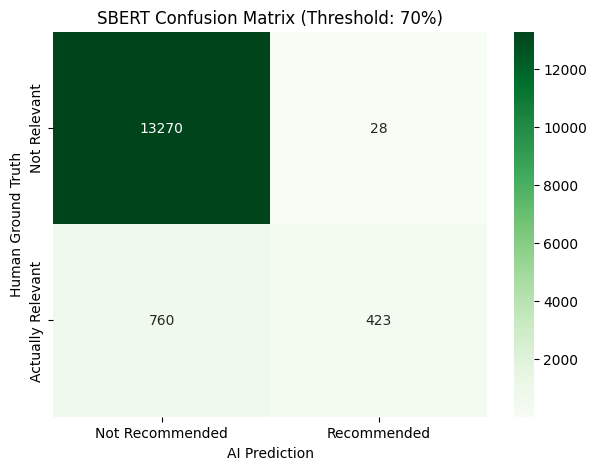

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# y_true: 1 if human says they are good, 0 otherwise
# Example: Anyone with the correct Job Role and at least 80% of required experience
merged_df['y_true'] = (
    (merged_df['resume_experience_years'] >= merged_df['required_experience_years_num'] * 0.8) & 
    (merged_df['skill_match_count'] > 0)
).astype(int)

# y_pred: 1 if AI score is high (e.g., > 80), 0 otherwise
# threshold = 80
# threshold = 75
threshold = 70
# threshold = 40
# threshold = 30
merged_df['y_pred'] = merged_df['Final_Match_Score'].apply(lambda x: 1 if x >= threshold else 0)

# 3. Generate Confusion Matrix
cm = confusion_matrix(merged_df['y_true'], merged_df['y_pred'])

# 4. Plotting
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Recommended', 'Recommended'], 
            yticklabels=['Not Relevant', 'Actually Relevant'])

plt.title(f'SBERT Confusion Matrix (Threshold: {threshold}%)')
plt.xlabel('AI Prediction')
plt.ylabel('Human Ground Truth')
plt.savefig('confusion_matrix.png')

# 5. Print the Technical Report
print(classification_report(merged_df['y_true'], merged_df['y_pred'], target_names=['Not Relevant', 'Relevant']))

In [45]:
'''
Since you are doing classification, the ultimate way to prove your model is better than TF-IDF or Word2Vec is the ROC-AUC (Receiver Operating Characteristic - Area Under Curve).
It measures how well your model separates the "Hires" from the "Rejects" across all possible thresholds.
'''
from sklearn.metrics import roc_auc_score, roc_curve

# Calculate AUC for your best model : 0.5 (random) while 0.8+ Excellent in recruitment industry
auc_bert = roc_auc_score(merged_df['y_true'], merged_df['Final_Match_Score'])
auc_tfidf = roc_auc_score(merged_df['y_true'], merged_df['tfidf_similarity'])
auc_w2v = roc_auc_score(merged_df['y_true'], merged_df['w2v_similarity'])

print(f"ROC-AUC Score: {auc_bert:.2f}")
print(f"ROC-AUC Score: {auc_tfidf:.2f}")
print(f"ROC-AUC Score: {auc_w2v:.2f}")


ROC-AUC Score: 0.96
ROC-AUC Score: 0.86
ROC-AUC Score: 0.83


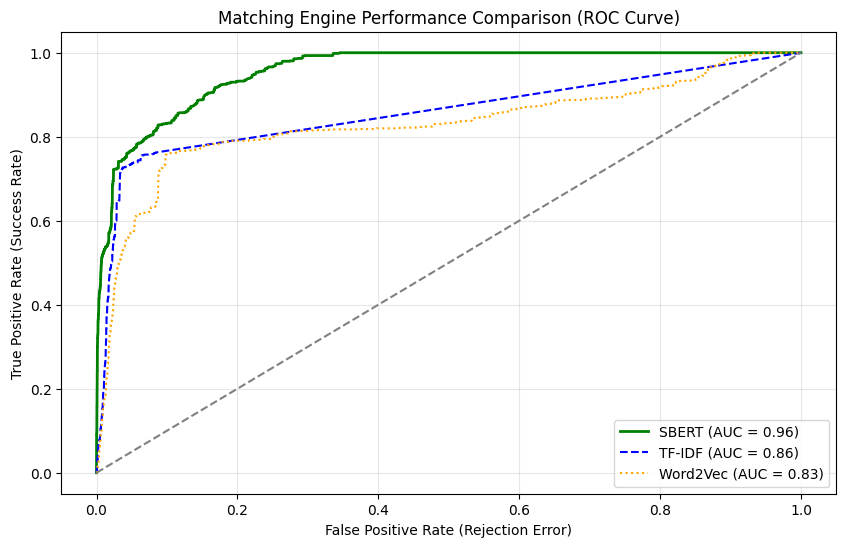

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Calculate curves
fpr_bert, tpr_bert, _ = roc_curve(merged_df['y_true'], merged_df['Final_Match_Score'])
fpr_tfidf, tpr_tfidf, _ = roc_curve(merged_df['y_true'], merged_df['tfidf_similarity'])
fpr_w2v, tpr_w2v, _ = roc_curve(merged_df['y_true'], merged_df['w2v_similarity'])

plt.figure(figsize=(10, 6))
plt.plot(fpr_bert, tpr_bert, label=f'SBERT (AUC = {auc_bert:.2f})', color='green', lw=2)
plt.plot(fpr_tfidf, tpr_tfidf, label=f'TF-IDF (AUC = {auc_tfidf:.2f})', color='blue', linestyle='--')
plt.plot(fpr_w2v, tpr_w2v, label=f'Word2Vec (AUC = {auc_w2v:.2f})', color='orange', linestyle=':')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random baseline

plt.title('Matching Engine Performance Comparison (ROC Curve)')
plt.xlabel('False Positive Rate (Rejection Error)')
plt.ylabel('True Positive Rate (Success Rate)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [47]:
def generate_explanation_v4(row):
    # 1. Experience Note
    gap = row['experience_gap']
    if gap >= 0:
        exp_text = f"Meets or exceeds requirements (Has: {row['resume_experience_years']} yrs)."
    else:
        exp_text = f"Experience gap of {abs(gap)} years detected."

    # 2. Skill Logic (Separating Direct vs Semantic matches)
    matched = row['matched_skills_list']
    required = row['required_skills_list']
    missing = [s for s in required if s not in matched]
    
    # 3. Dynamic AI Note based on Score
    score = row['Final_Match_Score']
    if score >= 80:
        insight = "Strong candidate: Technical background is a direct match for job complexity."
    elif score >= 65:
        insight = "Potential match: Transferable skills identified despite keyword gaps."
    else:
        insight = "Low alignment: Candidate background deviates significantly from core requirements."

    return (
        f"**Summary:** {row['name']} ({score}%)\n"
        f"- **Exp:** {exp_text}\n"
        f"- **Skills:** Matched {len(matched)} key skills: {', '.join(matched)}.\n"
        f"- **Gaps:** Missing: {', '.join(missing) if missing else 'None'}.\n"
        f"- **AI Note:** {insight}"
    )

merged_df['Detailed_Explanation'] = merged_df.apply(generate_explanation_v4, axis=1)
merged_df.columns


Index(['name', 'job_role', 'resume_skills', 'education', 'certifications',
       'resume_experience_years', 'Recruiter Decision', 'label',
       'resume_skills_list', 'required_experience_years_num',
       'required_skills', 'keywords', 'required_skills_list', 'keywords_list',
       'resume_text_for_bert', 'job_text_for_bert', 'experience_gap',
       'matched_skills_list', 'skill_match_count', 'y_true', 'resume_text',
       'job_text', 'semantic_similarity_score', 'boosted_semantic_score',
       'Final_Match_Score', 'tfidf_similarity', 'w2v_similarity',
       'is_objectively_good', 'y_pred', 'Detailed_Explanation'],
      dtype='object')

In [56]:
'''
Rank candidates using multiple levels
# 1. Match Score (Primary)
# 2. Experience Years (Secondary)
# 3. Raw Semantic Score (Tertiary - the ultimate tie-breaker)
# 4. Skill Density (Quaternary)
'''
# option 4 as last resort
merged_df['skill_density'] = merged_df['skill_match_count'] / merged_df['resume_skills_list'].apply(len)

# Set the max column width to None (unlimited)
pd.set_option('display.max_colwidth', None)


'''
rank by skill density 
The "Expertise" (candidate lists 5 skills, and 4 of them match your job) vs. 
"Generalist" Metric (A candidate lists 50 skills, and 4 of them match your job.)
'''
# ranked_results = merged_df[['name','job_role' ,'semantic_similarity_score', 'skill_density', 'Final_Match_Score', 'Detailed_Explanation','experience_gap']].sort_values(
#     by=['skill_density'], ascending=[False]
# )

'''
rank by job
'''
# ranked_results.groupby('job_role').head(1)
ranked_results.groupby('job_role').head()
# ranked_results.groupby('job_role').head(1)['Detailed_Explanation']
# ranked_results.groupby('job_role').head()['Detailed_Explanation']
# ranked_results.groupby('job_role').head(1)['Explanation']


'''
rank by score and experience
'''
ranked_results = merged_df[['name','job_role' ,'semantic_similarity_score', 'Final_Match_Score', 'Detailed_Explanation']].sort_values(
    by=['Final_Match_Score','semantic_similarity_score'], ascending=[False,False]
).head()

# Preview the top candidate on final score
# max(merged_df['Final_Match_Score'])
# ranked_results.groupby('Final_Match_Score').head(1)
# ranked_results.groupby('Final_Match_Score').head(1)['Detailed_Explanation']
# ranked_results.head(1)
# ranked_results.head(1)['Detailed_Explanation']


# matching_skills_mask = merged_df['matched_skills_list'].apply(len) > 0

# # Filter the dataframe
# rows_with_matches = merged_df[matching_skills_mask]

# # Display a few key columns to verify
# print(f"Found {len(rows_with_matches)} candidates with direct skill matches.")
# display(rows_with_matches[['Name', 'job_role', 'matched_skills_list', 'skill_match_count']].head())
ranked_results

,name,job_role,semantic_similarity_score,Final_Match_Score,Detailed_Explanation
522,jack thompson,project manager,87.13,92.27,"**Summary:** jack thompson (92.27%)\n- **Exp:** Experience gap of 7.0 years detected.\n- **Skills:** Matched 10 key skills: trello, advanced project planning, scheduling and budgeting, jira, use of project management tools ms project, reporting and dashboards, risk and quality management, change management, team leadership, conflict resolution.\n- **Gaps:** Missing: strategic alignment, stakeholder engagement.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity."
242,emily johnson,data engineer,79.39,91.05,"**Summary:** emily johnson (91.05%)\n- **Exp:** Experience gap of 4.0 years detected.\n- **Skills:** Matched 7 key skills: sql, snowflake, hadoop, airflow, java, python, apache kafka.\n- **Gaps:** Missing: aws glue.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity."
733,marcus thompson,data engineer,79.34,91.02,"**Summary:** marcus thompson (91.02%)\n- **Exp:** Experience gap of 4.0 years detected.\n- **Skills:** Matched 7 key skills: sql, snowflake, hadoop, airflow, java, python, apache kafka.\n- **Gaps:** Missing: aws glue.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity."
328,ewa kowalska,data engineer,70.63,90.37,"**Summary:** ewa kowalska (90.37%)\n- **Exp:** Experience gap of 5.0 years detected.\n- **Skills:** Matched 8 key skills: sql, aws redshift, azure data lake, airflow, spark, kafka, java, python.\n- **Gaps:** Missing: None.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity."
348,farida khan,data engineer,77.72,90.20,"**Summary:** farida khan (90.2%)\n- **Exp:** Experience gap of 5.0 years detected.\n- **Skills:** Matched 7 key skills: sql, azure data lake, airflow, spark, kafka, java, python.\n- **Gaps:** Missing: aws redshift.\n- **AI Note:** Strong candidate: Technical background is a direct match for job complexity."


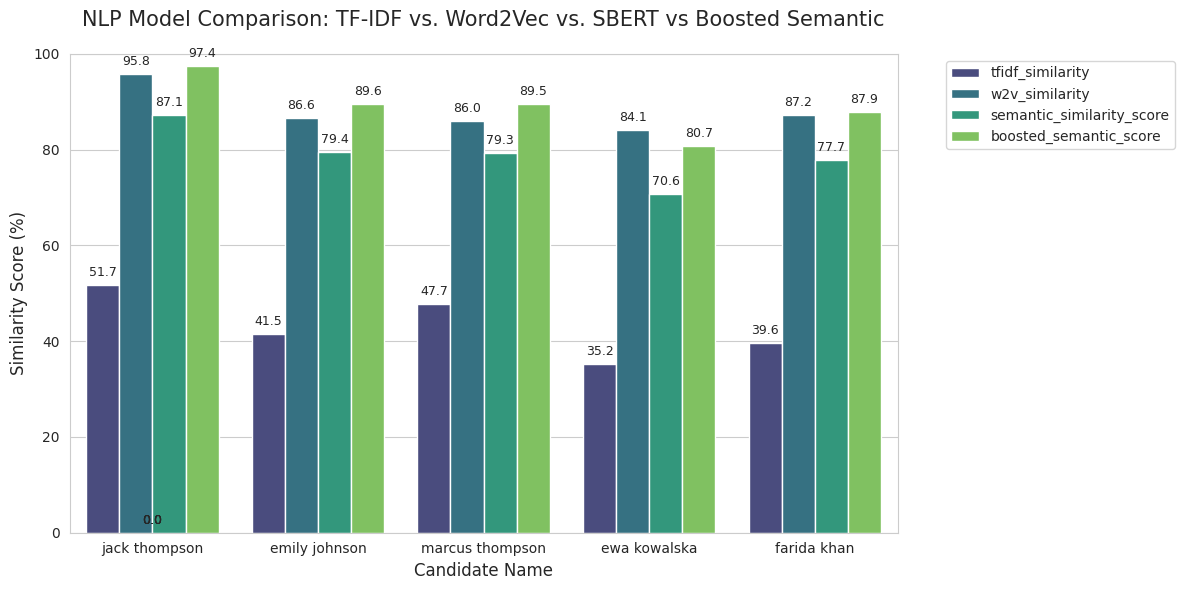

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Select the top 5 candidates to keep the chart clean
top_candidates = merged_df.nlargest(5, 'Final_Match_Score')

# 2. Melt the dataframe to make it 'Long-form' (perfect for Seaborn bar charts)
plot_data = top_candidates.melt(
# plot_data = top_candidate.melt(
    id_vars=['name'], 
    value_vars=['tfidf_similarity', 'w2v_similarity', 'semantic_similarity_score','boosted_semantic_score'],
    var_name='Model Type', 
    value_name='Similarity Score'
)

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=plot_data, x='name', y='Similarity Score', hue='Model Type', palette='viridis')

# Add labels and title
plt.title('NLP Model Comparison: TF-IDF vs. Word2Vec vs. SBERT vs Boosted Semantic', fontsize=15, pad=20)
plt.ylabel('Similarity Score (%)', fontsize=12)
plt.xlabel('Candidate Name', fontsize=12)
plt.ylim(0, 100) # Ensure scale is comparable
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=9)

plt.tight_layout()
plt.show()

In [58]:
import joblib
! pip install joblib
# Create a folder for your model assets
os.makedirs('model_assets_2', exist_ok=True)

# 1. Save the SentenceTransformer (SBERT) model
# This saves weights, config, and the tokenizer in one folder
model.save('model_assets_2/sbert_model_2')

# 2. Save the MinMaxScaler
# We use joblib because it's more efficient for scikit-learn objects
joblib.dump(scaler, 'model_assets_2/semantic_scaler_2.pkl')

print("Model and Scaler saved successfully in 'model_assets_2/'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Scaler saved successfully in 'model_assets_2/'


In [59]:
import shutil
from IPython.display import FileLink

# 1. Zip the folder
# This creates 'model_assets_2.zip' from the 'model_assets_2' directory
shutil.make_archive('model_assets_2', 'zip', 'model_assets_2')

# 2. Generate a download link
FileLink(r'model_assets_2.zip')

/kaggle/working/model_assets_2.zip